# 03. Thresholds, Alerts, and Decision Costs

An anomaly score ranks cases by suspiciousness. A threshold turns that ranking into an operational alert queue. This is where many anomaly-detection projects become fragile: the model may be technically reasonable, but the threshold can overload analysts, miss severe incidents, or create a large volume of low-value false alarms.

This lecture treats thresholding as a decision problem. We will work with a synthetic transaction-review setting where an anomaly score is already available. The task is not to build the score. The task is to decide how to use it.

The central message is: a threshold is a policy. It should be selected with explicit costs, review capacity, precision-recall behavior, and escalation rules.

## Learning Objectives

By the end of this lecture, you should be able to:

1. Convert an anomaly score into an alert rule using a threshold.
2. Compute threshold-dependent confusion-matrix quantities.
3. Explain why precision-recall curves are often more informative than ROC curves for rare anomalies.
4. Define an expected-utility function for alert policies.
5. Compare utility-maximizing thresholds with capacity-constrained top-k policies.
6. Explain how alert fatigue changes the value of threshold choices.
7. Create a threshold-selection memo that ties statistical performance to operational action.
8. Diagnose when a single global threshold should be replaced with segment-specific or tiered review rules.

In [1]:
# Section focus: Learning Objectives.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, roc_curve

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'notebooks' / '_shared' / 'display.py').exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 160)

RANDOM_SEED = 2028

## 1. Thresholds Are Decision Rules

Let $s_i \in [0,1]$ be an anomaly score for case $i$. Larger values mean higher suspiciousness. A threshold policy is

$$
d_i(t) = \mathbf{1}\{s_i \ge t\},
$$

where $d_i(t)=1$ means the case enters the alert queue.

If $Y_i \in \{0,1\}$ indicates whether the case is truly anomalous, the threshold creates four counts:

$$
\mathrm{TP}(t) = \sum_i \mathbf{1}\{d_i(t)=1, Y_i=1\},
$$

$$
\mathrm{FP}(t) = \sum_i \mathbf{1}\{d_i(t)=1, Y_i=0\},
$$

$$
\mathrm{FN}(t) = \sum_i \mathbf{1}\{d_i(t)=0, Y_i=1\},
$$

$$
\mathrm{TN}(t) = \sum_i \mathbf{1}\{d_i(t)=0, Y_i=0\}.
$$

The same score can therefore support many different alert systems. The threshold determines which errors the organization chooses to tolerate.

### Metrics Attached to a Threshold

For anomaly detection, the most important threshold-dependent quantities are:

$$
\mathrm{Precision}(t) = \frac{\mathrm{TP}(t)}{\mathrm{TP}(t)+\mathrm{FP}(t)},
$$

$$
\mathrm{Recall}(t) = \frac{\mathrm{TP}(t)}{\mathrm{TP}(t)+\mathrm{FN}(t)},
$$

$$
\text{False Positive Rate}(t) = \frac{\mathrm{FP}(t)}{\mathrm{FP}(t)+\mathrm{TN}(t)},
$$

$$
\text{Alert Rate}(t) = \frac{\mathrm{TP}(t)+\mathrm{FP}(t)}{n}.
$$

Precision asks, "Of the cases we send to analysts, how many are real?" Recall asks, "Of the real anomalies, how many do we catch?" Alert rate asks, "How much work did we create?"

## 2. Synthetic Case: Transaction Review Queue

Suppose a payment platform produces an anomaly score for each transaction. Analysts can review only a limited number of cases per day. The score combines signals such as transaction amount, device risk, velocity, account age, and vendor history.

We will simulate a realistic rare-event setting:

| Item | Case-study meaning |
|---|---|
| Unit | One transaction |
| Score | Existing anomaly score from a monitoring model |
| Label | Whether later investigation shows a material anomaly |
| Action | Send to analyst review, suppress, or escalate |
| Cost of false alert | Analyst time, customer friction, queue congestion |
| Cost of miss | Chargeback, fraud loss, compliance incident, reputational risk |
| Constraint | Review team has finite daily capacity |

In [2]:
def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1.0 / (1.0 + np.exp(-z))


def simulate_transaction_review_queue(n=9000, seed=RANDOM_SEED):
    """Create a simulated transaction review queue data set for the 03. Thresholds, Alerts, and Decision Costs case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(seed)

    segment = rng.choice(['consumer', 'small_business', 'enterprise'], size=n, p=[0.58, 0.31, 0.11])
    channel = rng.choice(['card', 'ach', 'wire', 'instant'], size=n, p=[0.52, 0.24, 0.10, 0.14])

    segment_shift = np.select(
        [segment == 'consumer', segment == 'small_business', segment == 'enterprise'],
        [-0.15, 0.20, 0.55],
    )
    channel_shift = np.select(
        [channel == 'card', channel == 'ach', channel == 'wire', channel == 'instant'],
        [0.00, 0.08, 0.45, 0.22],
    )

    log_amount = rng.normal(5.7 + segment_shift + channel_shift, 0.72, n)
    amount = np.exp(log_amount)
    device_risk = np.clip(rng.beta(1.5, 8.5, n) + 0.07 * (channel == 'instant'), 0, 1)
    velocity_1h = rng.poisson(1.0 + 0.35 * (channel == 'instant') + 0.30 * (segment == 'small_business'), n)
    account_age_days = np.clip(rng.gamma(2.2 + 0.8 * (segment == 'enterprise'), 140, n), 2, 2600)
    prior_clean_transactions = np.clip(rng.lognormal(3.1 + 0.65 * (segment == 'enterprise'), 0.75, n), 1, 1400)
    cross_border = rng.binomial(1, 0.12 + 0.10 * (channel == 'wire') + 0.05 * (segment == 'enterprise'), n)

    log_amount_z = (log_amount - log_amount.mean()) / log_amount.std(ddof=0)
    velocity_z = (velocity_1h - velocity_1h.mean()) / velocity_1h.std(ddof=0)
    age_z = (np.log1p(account_age_days) - np.log1p(account_age_days).mean()) / np.log1p(account_age_days).std(ddof=0)
    clean_history_z = (np.log1p(prior_clean_transactions) - np.log1p(prior_clean_transactions).mean()) / np.log1p(prior_clean_transactions).std(ddof=0)

    true_logit = (
        -4.85
        + 0.72 * log_amount_z
        + 2.25 * device_risk
        + 0.36 * velocity_z
        + 0.52 * cross_border
        + 0.28 * (channel == 'wire')
        - 0.42 * age_z
        - 0.32 * clean_history_z
    )
    true_probability = sigmoid(true_logit)
    known_anomaly = rng.binomial(1, true_probability)

    # The production score is useful but imperfect: it sees the same signals with noise and slight miscalibration.
    score_logit = (
        -3.85
        + 0.68 * log_amount_z
        + 2.00 * device_risk
        + 0.42 * velocity_z
        + 0.35 * cross_border
        + 0.22 * (channel == 'wire')
        - 0.26 * age_z
        - 0.22 * clean_history_z
        + rng.normal(0, 0.62, n)
    )
    anomaly_score = sigmoid(score_logit)

    # Potential severity is not the same as anomaly probability; high-value misses hurt more.
    potential_loss = np.clip(0.18 * amount * (1 + 2.8 * device_risk + 0.5 * cross_border), 20, 12_000)
    review_minutes = np.clip(8 + 5 * (channel == 'wire') + 2.5 * cross_border + rng.normal(0, 1.2, n), 4, 24)

    return pd.DataFrame({
        'segment': segment,
        'channel': channel,
        'amount': amount,
        'device_risk': device_risk,
        'velocity_1h': velocity_1h,
        'account_age_days': account_age_days,
        'prior_clean_transactions': prior_clean_transactions,
        'cross_border': cross_border,
        'true_probability': true_probability,
        'anomaly_score': anomaly_score,
        'known_anomaly': known_anomaly,
        'potential_loss': potential_loss,
        'review_minutes': review_minutes,
    })


df = simulate_transaction_review_queue()
preview = df.head()[['segment', 'channel', 'amount', 'device_risk', 'velocity_1h', 'cross_border', 'anomaly_score', 'known_anomaly', 'potential_loss']].copy()
preview[['amount', 'device_risk', 'anomaly_score', 'potential_loss']] = preview[['amount', 'device_risk', 'anomaly_score', 'potential_loss']].round(3)
smart_display(preview, max_width='120px')

,segment,channel,amount,device_risk,velocity_1h,cross_border,anomaly_score,known_anomaly,potential_loss
0,consumer,wire,457.755,0.220,0,0,0.047,0,133.252
1,small_business,card,580.924,0.371,2,0,0.189,0,213.293
2,small_business,card,224.077,0.098,3,0,0.040,0,51.376
3,enterprise,ach,1000.533,0.160,0,0,0.063,0,260.980
4,small_business,card,393.294,0.385,0,0,0.061,0,147.090


The practical reading of Synthetic Case: Transaction Review Queue is whether the flagged cases point to an action a team can defend.


In [3]:
# Section focus: 2. Synthetic Case: Transaction Review Queue.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

overview = pd.DataFrame({
    'Quantity': [
        'Transactions',
        'Known anomaly rate',
        'Average anomaly score',
        'Median anomaly score',
        'ROC AUC',
        'Average precision',
        'Median potential loss',
        'Average review minutes',
    ],
    'Value': [
        len(df),
        df['known_anomaly'].mean(),
        df['anomaly_score'].mean(),
        df['anomaly_score'].median(),
        roc_auc_score(df['known_anomaly'], df['anomaly_score']),
        average_precision_score(df['known_anomaly'], df['anomaly_score']),
        df['potential_loss'].median(),
        df['review_minutes'].mean(),
    ],
})
overview_display = overview.copy()
overview_display['Value'] = overview_display['Value'].map(lambda value: f'{value:,.0f}' if abs(value) >= 1000 else f'{value:.3f}')
smart_display(overview_display, max_width='620px')

,Quantity,Value
0,Transactions,"9,000"
1,Known anomaly rate,0.022
2,Average anomaly score,0.050
3,Median anomaly score,0.030
4,ROC AUC,0.716
5,Average precision,0.064
6,Median potential loss,90.001
7,Average review minutes,8.842


The base rate is low, so accuracy would be a poor metric. A model that never alerts could be highly accurate and operationally useless. For rare anomaly settings, precision, recall, review volume, and expected cost are more meaningful.

Precision-recall analysis is particularly useful in rare-outcome settings because ROC curves can make performance look stronger than the analyst queue actually feels (Cook & Ramadas, 2020; Saito & Rehmsmeier, 2016).

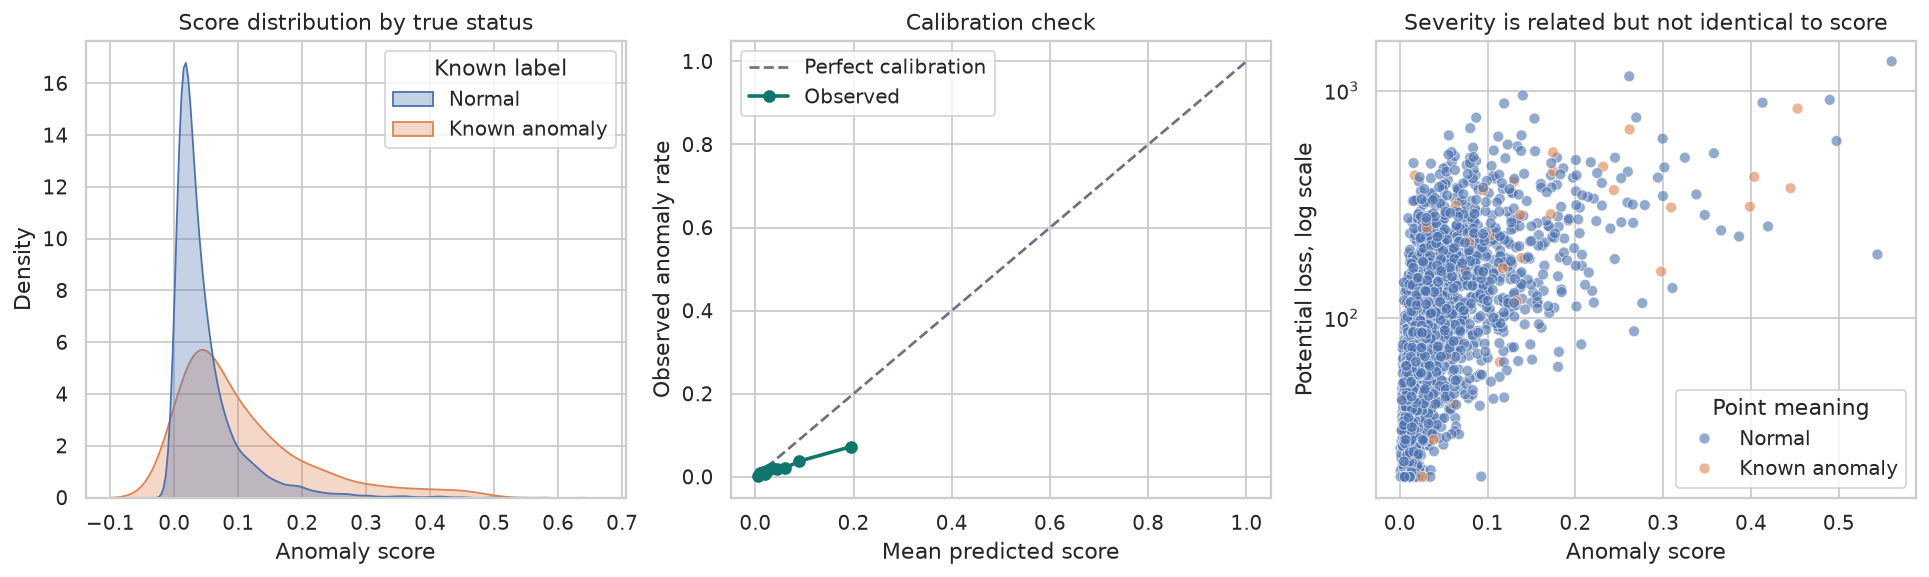

In [4]:
# Section focus: Discussion.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.6))
plot_df = df.copy()
plot_df['Known label'] = np.where(plot_df['known_anomaly'] == 1, 'Known anomaly', 'Normal')

sns.kdeplot(
    data=plot_df,
    x='anomaly_score',
    hue='Known label',
    hue_order=['Normal', 'Known anomaly'],
    common_norm=False,
    fill=True,
    alpha=0.32,
    ax=axes[0],
)
axes[0].set_title('Score distribution by true status')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Density')

prob_true, prob_pred = calibration_curve(df['known_anomaly'], df['anomaly_score'], n_bins=10, strategy='quantile')
axes[1].plot([0, 1], [0, 1], color='#6b7280', linestyle='--', label='Perfect calibration')
axes[1].plot(prob_pred, prob_true, marker='o', color='#0f766e', linewidth=2.0, label='Observed')
axes[1].set_title('Calibration check')
axes[1].set_xlabel('Mean predicted score')
axes[1].set_ylabel('Observed anomaly rate')
axes[1].legend()

sns.scatterplot(
    data=plot_df.sample(2200, random_state=RANDOM_SEED),
    x='anomaly_score',
    y='potential_loss',
    hue='Known label',
    hue_order=['Normal', 'Known anomaly'],
    alpha=0.60,
    ax=axes[2],
)
axes[2].set_yscale('log')
axes[2].set_title('Severity is related but not identical to score')
axes[2].set_xlabel('Anomaly score')
axes[2].set_ylabel('Potential loss, log scale')
axes[2].legend(title='Point meaning')

plt.tight_layout()
plt.show()

For Synthetic Case: Transaction Review Queue, separate unusual behavior from useful triage. The alert is valuable only when it changes the next review step.


## 3. Threshold Tables and Confusion Matrices

A threshold table makes the policy surface visible. For each threshold $t$, compute the confusion counts and operational metrics. A useful table should include alert volume because a threshold that looks statistically attractive may be impossible to staff.

Let

$$
A(t) = \sum_i d_i(t)
$$

be alert count. If each alert takes $m_i$ minutes, expected workload is

$$
W(t) = \sum_i d_i(t)m_i.
$$

This creates a direct bridge from model performance to analyst staffing.

In [5]:
# Section focus: 3. Threshold Tables and Confusion Matrices.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def safe_divide(num, den):
    """Carry out the safe divide step used in the 03. Thresholds, Alerts, and Decision Costs workflow.
    
    Parameters
    ----------
    num : object
        The num setting that controls the safe divide calculation in this notebook.
    den : object
        The den setting that controls the safe divide calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the safe divide calculation and reused by later cells.
    """
    return np.nan if den == 0 else num / den


def threshold_metrics(frame, score_col='anomaly_score', y_col='known_anomaly', thresholds=None):
    """Carry out the threshold metrics step used in the 03. Thresholds, Alerts, and Decision Costs workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    score_col : object
        Column name containing model scores, risks, priorities, or anomaly scores.
    y_col : object
        Column name containing the outcome or target used by the model.
    thresholds : object
        Candidate decision cutoffs compared by the evaluation step.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if thresholds is None:
        thresholds = np.linspace(0.02, 0.72, 141)
    y = frame[y_col].to_numpy()
    scores = frame[score_col].to_numpy()
    rows = []
    for threshold in thresholds:
        alert = scores >= threshold
        tp = int(((alert == 1) & (y == 1)).sum())
        fp = int(((alert == 1) & (y == 0)).sum())
        fn = int(((alert == 0) & (y == 1)).sum())
        tn = int(((alert == 0) & (y == 0)).sum())
        alerts = int(alert.sum())
        rows.append({
            'threshold': threshold,
            'alerts': alerts,
            'alert_rate': alerts / len(frame),
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'tn': tn,
            'precision': safe_divide(tp, tp + fp),
            'recall': safe_divide(tp, tp + fn),
            'false_positive_rate': safe_divide(fp, fp + tn),
            'workload_hours': frame.loc[alert, 'review_minutes'].sum() / 60,
            'captured_loss_share': safe_divide(frame.loc[alert & (frame[y_col] == 1), 'potential_loss'].sum(), frame.loc[frame[y_col] == 1, 'potential_loss'].sum()),
        })
    return pd.DataFrame(rows)

metric_table = threshold_metrics(df)
selected_thresholds = [0.05, 0.10, 0.18, 0.28, 0.40, 0.55]
threshold_summary = metric_table.iloc[(metric_table['threshold'].to_numpy()[:, None] - np.array(selected_thresholds)).__abs__().argmin(axis=0)].drop_duplicates('threshold')
threshold_display = threshold_summary[['threshold', 'alerts', 'alert_rate', 'precision', 'recall', 'false_positive_rate', 'workload_hours', 'captured_loss_share']].copy()
for column in ['threshold', 'workload_hours']:
    threshold_display[column] = threshold_display[column].map(lambda value: f'{value:.2f}')
for column in ['alert_rate', 'precision', 'recall', 'false_positive_rate', 'captured_loss_share']:
    threshold_display[column] = threshold_display[column].map(lambda value: f'{value:.1%}')
smart_display(threshold_display, max_width='900px')

,threshold,alerts,alert_rate,precision,recall,false_positive_rate,workload_hours,captured_loss_share
6,0.05,2790,31.0%,4.3%,60.7%,30.3%,432.68,80.0%
16,0.10,1133,12.6%,6.9%,39.8%,12.0%,179.16,59.9%
32,0.18,372,4.1%,8.9%,16.8%,3.9%,58.70,33.0%
52,0.28,116,1.3%,12.9%,7.7%,1.1%,18.34,15.7%
76,0.40,42,0.5%,11.9%,2.6%,0.4%,6.83,6.1%
106,0.55,6,0.1%,0.0%,0.0%,0.1%,1.17,0.0%


Threshold Tables and Confusion Matrices is less about the score itself and more about whether the score creates an actionable investigation path.


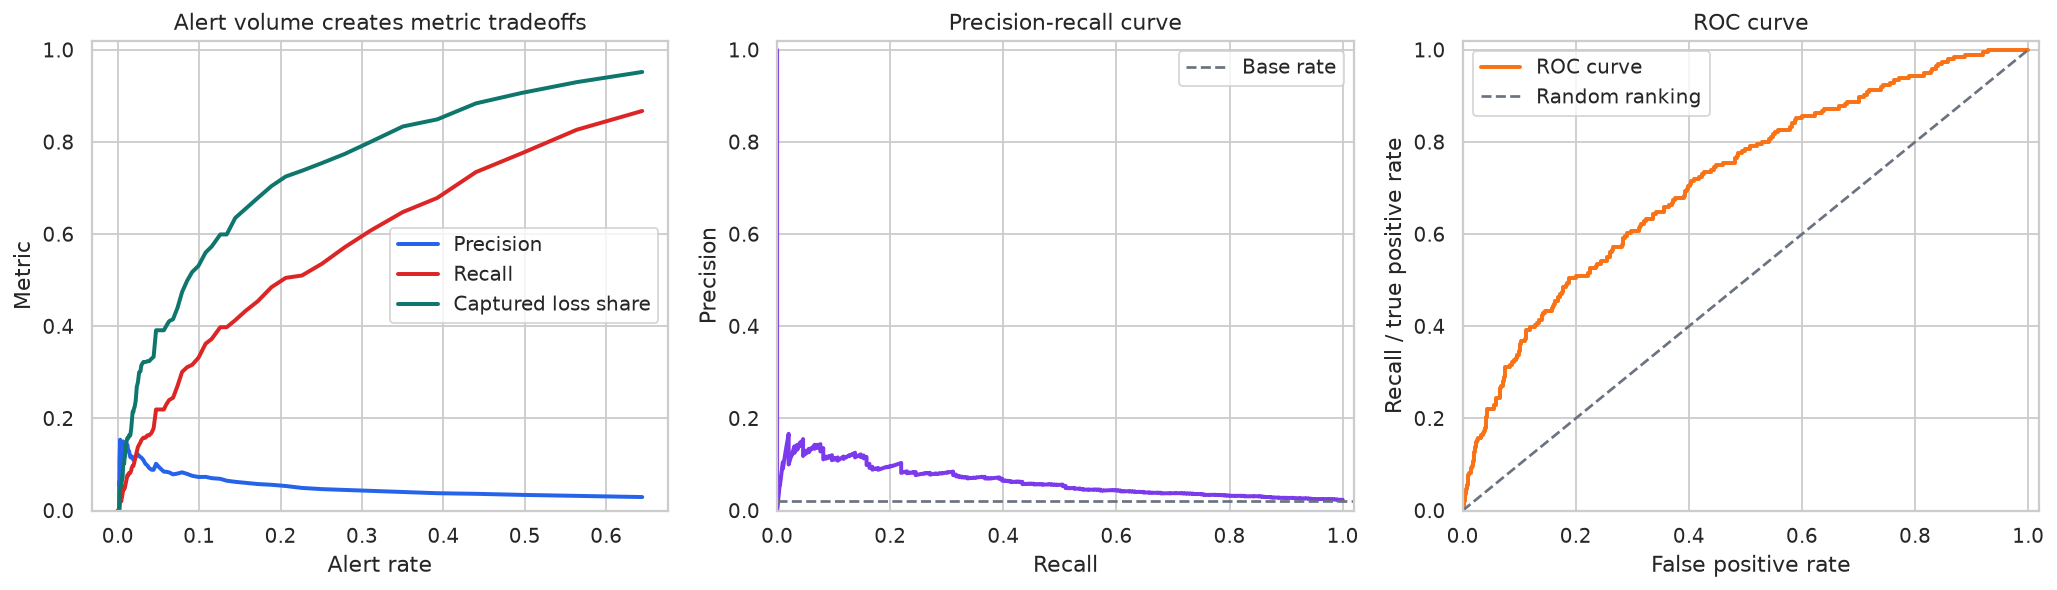

In [6]:
# Section focus: 3. Threshold Tables and Confusion Matrices.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.7))

axes[0].plot(metric_table['alert_rate'], metric_table['precision'], label='Precision', linewidth=2.2, color='#2563eb')
axes[0].plot(metric_table['alert_rate'], metric_table['recall'], label='Recall', linewidth=2.2, color='#dc2626')
axes[0].plot(metric_table['alert_rate'], metric_table['captured_loss_share'], label='Captured loss share', linewidth=2.2, color='#0f766e')
axes[0].set_title('Alert volume creates metric tradeoffs')
axes[0].set_xlabel('Alert rate')
axes[0].set_ylabel('Metric')
axes[0].set_ylim(0, 1.02)
axes[0].legend()

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(df['known_anomaly'], df['anomaly_score'])
axes[1].plot(recall_curve, precision_curve, color='#7c3aed', linewidth=2.2)
axes[1].axhline(df['known_anomaly'].mean(), color='#6b7280', linestyle='--', label='Base rate')
axes[1].set_title('Precision-recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].legend()

fpr, tpr, roc_thresholds = roc_curve(df['known_anomaly'], df['anomaly_score'])
axes[2].plot(fpr, tpr, color='#f97316', linewidth=2.2, label='ROC curve')
axes[2].plot([0, 1], [0, 1], color='#6b7280', linestyle='--', label='Random ranking')
axes[2].set_title('ROC curve')
axes[2].set_xlabel('False positive rate')
axes[2].set_ylabel('Recall / true positive rate')
axes[2].set_xlim(0, 1.02)
axes[2].set_ylim(0, 1.02)
axes[2].legend()

plt.tight_layout()
plt.show()

As thresholds become more permissive, recall and captured loss share rise because more true anomalies are reviewed. Precision usually falls because the queue contains more false alerts. This is why a single metric can be misleading.

The precision-recall curve is especially useful here because the base rate is low. The ROC curve still provides ranking information, but analyst teams experience precision, queue volume, and workload more directly than ROC AUC.

## 4. Expected Utility and Cost-Sensitive Thresholding

A cost-sensitive decision rule assigns value to true positives and costs to false positives, missed anomalies, and review work. One simple utility is

$$
U(t) = b_{\mathrm{tp}}\mathrm{TP}(t)
- c_{\mathrm{fp}}\mathrm{FP}(t)
- c_{\mathrm{fn}}\mathrm{FN}(t)
- c_{\mathrm{review}}A(t).
$$

In settings where anomalies have different severity, a more realistic version weights true positives and false negatives by potential loss:

$$
U(t) = v \cdot \sum_i d_i(t)Y_i L_i
- m \cdot \sum_i (1-d_i(t))Y_i L_i
- c_{\mathrm{fp}}\mathrm{FP}(t)
- c_{\mathrm{review}}A(t),
$$

where $L_i$ is potential loss. The parameters encode business priorities. Cost-sensitive learning and cost-sensitive thresholding exist because error types rarely have equal consequences (Zhou & Liu, 2010).

In [7]:
# Section focus: 4. Expected Utility and Cost-Sensitive Thresholding.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def utility_table(frame, metric_table, detected_loss_value=0.45, missed_loss_cost=0.70, false_alert_cost=22.0, review_cost=8.0):
    """Carry out the utility table step used in the 03. Thresholds, Alerts, and Decision Costs workflow.
    
    Parameters
    ----------
    frame : object
        Data frame containing the units evaluated by this helper.
    metric_table : object
        Tabular data object used as the input or output of this workflow step.
    detected_loss_value : object
        Operational value used to translate predictions into decision consequences.
    missed_loss_cost : object
        Cost value used to translate model errors into operational consequences.
    false_alert_cost : object
        Cost value used to translate model errors into operational consequences.
    review_cost : object
        Cost value used to translate model errors into operational consequences.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rows = []
    total_anomaly_loss = frame.loc[frame['known_anomaly'] == 1, 'potential_loss'].sum()
    for _, row in metric_table.iterrows():
        alert = frame['anomaly_score'] >= row['threshold']
        y = frame['known_anomaly'] == 1
        captured_loss = frame.loc[alert & y, 'potential_loss'].sum()
        missed_loss = total_anomaly_loss - captured_loss
        false_alerts = int((alert & ~y).sum())
        alerts = int(alert.sum())
        utility = detected_loss_value * captured_loss - missed_loss_cost * missed_loss - false_alert_cost * false_alerts - review_cost * alerts
        rows.append({
            'threshold': row['threshold'],
            'alert_rate': row['alert_rate'],
            'alerts': alerts,
            'precision': row['precision'],
            'recall': row['recall'],
            'captured_loss_share': row['captured_loss_share'],
            'utility': utility,
            'utility_per_transaction': utility / len(frame),
        })
    return pd.DataFrame(rows)

base_utility = utility_table(df, metric_table)
scarce_review_utility = utility_table(df, metric_table, detected_loss_value=0.45, missed_loss_cost=0.70, false_alert_cost=35.0, review_cost=22.0)
high_miss_cost_utility = utility_table(df, metric_table, detected_loss_value=0.50, missed_loss_cost=1.10, false_alert_cost=18.0, review_cost=8.0)

utility_scenarios = {
    'Base utility': base_utility,
    'Scarce analyst capacity': scarce_review_utility,
    'High missed-loss cost': high_miss_cost_utility,
}

best_rows = []
for scenario, table in utility_scenarios.items():
    best = table.loc[table['utility'].idxmax()].copy()
    best_rows.append({
        'scenario': scenario,
        'threshold': best['threshold'],
        'alerts': int(best['alerts']),
        'alert_rate': best['alert_rate'],
        'precision': best['precision'],
        'recall': best['recall'],
        'captured_loss_share': best['captured_loss_share'],
        'utility_per_transaction': best['utility_per_transaction'],
    })
best_policy_table = pd.DataFrame(best_rows)
best_policy_display = best_policy_table.copy()
best_policy_display['threshold'] = best_policy_display['threshold'].map(lambda value: f'{value:.3f}')
best_policy_display['utility_per_transaction'] = best_policy_display['utility_per_transaction'].map(lambda value: f'{value:,.2f}')
for column in ['alert_rate', 'precision', 'recall', 'captured_loss_share']:
    best_policy_display[column] = best_policy_display[column].map(lambda value: f'{value:.1%}')
smart_display(best_policy_display, max_width='920px')

,scenario,threshold,alerts,alert_rate,precision,recall,captured_loss_share,utility_per_transaction
0,Base utility,0.205,261,2.9%,11.5%,15.3%,31.6%,-2.60
1,Scarce analyst capacity,0.215,236,2.6%,11.9%,14.3%,30.0%,-3.28
2,High missed-loss cost,0.170,423,4.7%,10.2%,21.9%,39.1%,-3.67


Read Expected Utility and Cost-Sensitive Thresholding with the reviewer in mind. The result should help reviewers separate urgent cases from background variation.


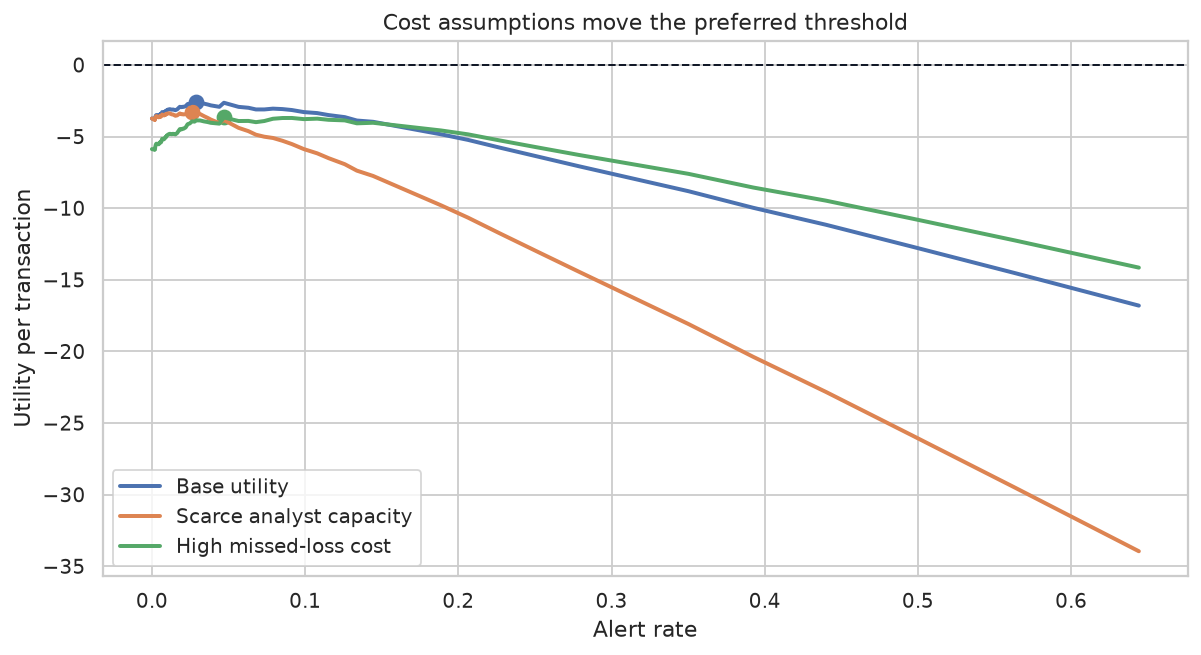

In [8]:
fig, ax = plt.subplots(figsize=(9.4, 5.2))
for scenario, table in utility_scenarios.items():
    ax.plot(table['alert_rate'], table['utility_per_transaction'], linewidth=2.2, label=scenario)
    best = table.loc[table['utility'].idxmax()]
    ax.scatter(best['alert_rate'], best['utility_per_transaction'], s=60)
ax.axhline(0, color='#111827', linestyle='--', linewidth=1.1)
ax.set_title('Cost assumptions move the preferred threshold')
ax.set_xlabel('Alert rate')
ax.set_ylabel('Utility per transaction')
ax.legend()
plt.tight_layout()
plt.show()

Changing cost assumptions changes the preferred threshold. Scarce review capacity makes false alerts and review work more expensive, so the best policy becomes more selective. Higher missed-loss cost pushes the policy toward reviewing more cases.

This is a feature, not a bug. Threshold choice should respond to business priorities. What matters is that those priorities are explicit, reviewable, and revisited when conditions change.

## 5. Capacity-Constrained Top-k Policies

Many anomaly systems do not choose a probability threshold directly. They choose a daily or hourly queue size. If analysts can review $k$ cases, the policy is

$$
d_i(k) = \mathbf{1}\{s_i \text{ is among the top } k \text{ scores}\}.
$$

This policy controls workload exactly in the batch, but its implied score threshold can drift over time as the score distribution changes. A top-k policy should therefore report both capacity and the realized score cutoff.

In [9]:
topk_rows = []
y = df['known_anomaly'].eq(1)
for review_rate in [0.005, 0.01, 0.02, 0.04, 0.08, 0.12]:
    k = int(np.ceil(review_rate * len(df)))
    selected_idx = df['anomaly_score'].nlargest(k).index
    selected = pd.Series(df.index.isin(selected_idx), index=df.index)
    topk_rows.append({
        'target_review_rate': review_rate,
        'k_alerts': k,
        'score_cutoff': df.loc[selected_idx, 'anomaly_score'].min(),
        'precision': df.loc[selected, 'known_anomaly'].mean(),
        'recall': selected.loc[y].mean(),
        'captured_loss_share': df.loc[selected & y, 'potential_loss'].sum() / df.loc[y, 'potential_loss'].sum(),
        'workload_hours': df.loc[selected, 'review_minutes'].sum() / 60,
    })
topk_table = pd.DataFrame(topk_rows)
topk_display = topk_table.copy()
topk_display['score_cutoff'] = topk_display['score_cutoff'].map(lambda value: f'{value:.3f}')
topk_display['workload_hours'] = topk_display['workload_hours'].map(lambda value: f'{value:.1f}')
for column in ['target_review_rate', 'precision', 'recall', 'captured_loss_share']:
    topk_display[column] = topk_display[column].map(lambda value: f'{value:.1%}')
smart_display(topk_display, max_width='920px')

,target_review_rate,k_alerts,score_cutoff,precision,recall,captured_loss_share,workload_hours
0,0.5%,45,0.398,13.3%,3.1%,6.7%,7.3
1,1.0%,90,0.310,13.3%,6.1%,14.1%,14.4
2,2.0%,180,0.240,11.1%,10.2%,22.2%,27.9
3,4.0%,360,0.183,9.2%,16.8%,33.0%,56.9
4,8.0%,720,0.130,8.3%,30.6%,49.4%,114.7
5,12.0%,1080,0.103,7.1%,39.3%,59.6%,171.1


In Capacity-Constrained Top-k Policies, the useful signal is the part that survives contact with seasonality, measurement noise, and routine variation.


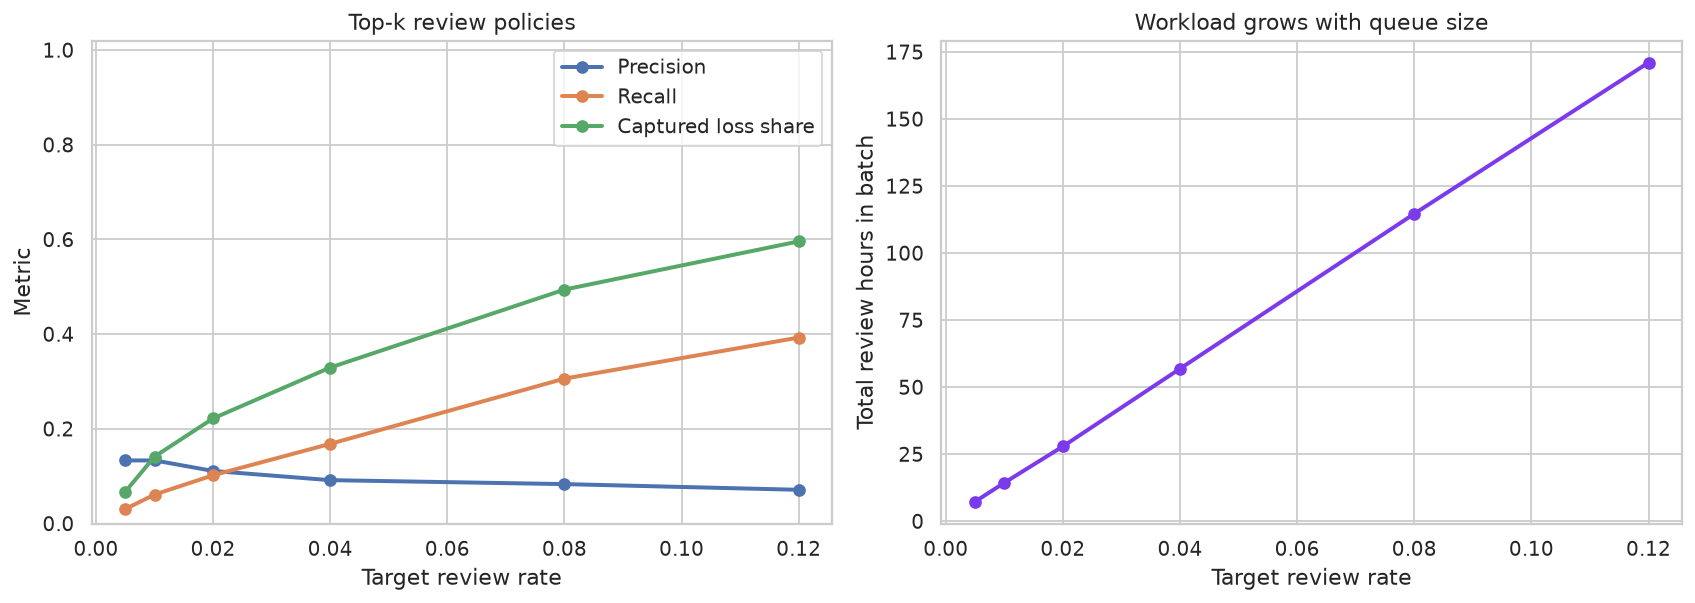

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

axes[0].plot(topk_table['target_review_rate'], topk_table['precision'], marker='o', linewidth=2.2, label='Precision')
axes[0].plot(topk_table['target_review_rate'], topk_table['recall'], marker='o', linewidth=2.2, label='Recall')
axes[0].plot(topk_table['target_review_rate'], topk_table['captured_loss_share'], marker='o', linewidth=2.2, label='Captured loss share')
axes[0].set_title('Top-k review policies')
axes[0].set_xlabel('Target review rate')
axes[0].set_ylabel('Metric')
axes[0].set_ylim(0, 1.02)
axes[0].legend()

axes[1].plot(topk_table['target_review_rate'], topk_table['workload_hours'], marker='o', linewidth=2.2, color='#7c3aed')
axes[1].set_title('Workload grows with queue size')
axes[1].set_xlabel('Target review rate')
axes[1].set_ylabel('Total review hours in batch')

plt.tight_layout()
plt.show()

Top-k policies are easy to operate because they match staffing constraints. Their weakness is that they hide the score threshold. If the entire score distribution shifts upward, the team still reviews $k$ cases, but the underlying risk level of the reviewed cases may change.

For governance, a top-k policy should log the realized cutoff, precision estimate, review hours, and downstream analyst dispositions.

## 6. Alert Fatigue and Workload Penalties

False alerts are statistical errors with operational costs. They consume attention. In security and monitoring systems, large numbers of alerts can create alert fatigue, causing important alerts to be lost in noise or slowing investigation (Hassan et al., 2019). A decision model can represent this by adding a workload penalty once alerts exceed capacity.

Let $C$ be review capacity in hours. If policy $t$ generates workload $W(t)$, one overload penalty is

$$
P_{\mathrm{overload}}(t) = \lambda \cdot \max\{0, W(t)-C\}^2.
$$

The square reflects that overload often becomes disproportionately costly: backlogs grow, analysts rush, and investigation quality falls.

In [11]:
# Section focus: 6. Alert Fatigue and Workload Penalties.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

daily_capacity_hours = 25
fatigue_penalty_lambda = 30

fatigue_table = base_utility.copy()
fatigue_table = fatigue_table.merge(metric_table[['threshold', 'workload_hours']], on='threshold', how='left')
fatigue_table['over_capacity_hours'] = np.maximum(0, fatigue_table['workload_hours'] - daily_capacity_hours)
fatigue_table['fatigue_penalty'] = fatigue_penalty_lambda * fatigue_table['over_capacity_hours'] ** 2
fatigue_table['fatigue_adjusted_utility'] = fatigue_table['utility'] - fatigue_table['fatigue_penalty']
fatigue_table['fatigue_adjusted_utility_per_transaction'] = fatigue_table['fatigue_adjusted_utility'] / len(df)

fatigue_best = fatigue_table.loc[fatigue_table['fatigue_adjusted_utility'].idxmax()]
base_best = fatigue_table.loc[fatigue_table['utility'].idxmax()]
summary_rows = []
for policy_name, row in [('Base utility optimum', base_best), ('Fatigue-adjusted optimum', fatigue_best)]:
    summary_rows.append({
        'policy': policy_name,
        'threshold': row['threshold'],
        'alerts': int(row['alerts']),
        'alert_rate': row['alert_rate'],
        'precision': row['precision'],
        'recall': row['recall'],
        'workload_hours': row['workload_hours'],
        'over_capacity_hours': row['over_capacity_hours'],
        'base_utility_per_transaction': row['utility_per_transaction'],
        'fatigue_adjusted_utility_per_transaction': row['fatigue_adjusted_utility_per_transaction'],
    })
fatigue_summary = pd.DataFrame(summary_rows)
fatigue_display = fatigue_summary.copy()
fatigue_display['threshold'] = fatigue_display['threshold'].map(lambda value: f'{value:.3f}')
fatigue_display['workload_hours'] = fatigue_display['workload_hours'].map(lambda value: f'{value:.1f}')
fatigue_display['over_capacity_hours'] = fatigue_display['over_capacity_hours'].map(lambda value: f'{value:.1f}')
for column in ['base_utility_per_transaction', 'fatigue_adjusted_utility_per_transaction']:
    fatigue_display[column] = fatigue_display[column].map(lambda value: f'{value:.2f}')
for column in ['alert_rate', 'precision', 'recall']:
    fatigue_display[column] = fatigue_display[column].map(lambda value: f'{value:.1%}')
smart_display(fatigue_display, max_width='1040px')

,policy,threshold,alerts,alert_rate,precision,recall,workload_hours,over_capacity_hours,base_utility_per_transaction,fatigue_adjusted_utility_per_transaction
0,Base utility optimum,0.205,261,2.9%,11.5%,15.3%,40.8,15.8,-2.60,-3.43
1,Fatigue-adjusted optimum,0.250,164,1.8%,11.6%,9.7%,25.4,0.4,-2.92,-2.92


For Alert Fatigue and Workload Penalties, focus on what the alert would make an analyst do next: investigate, suppress, monitor, or revise the rule.


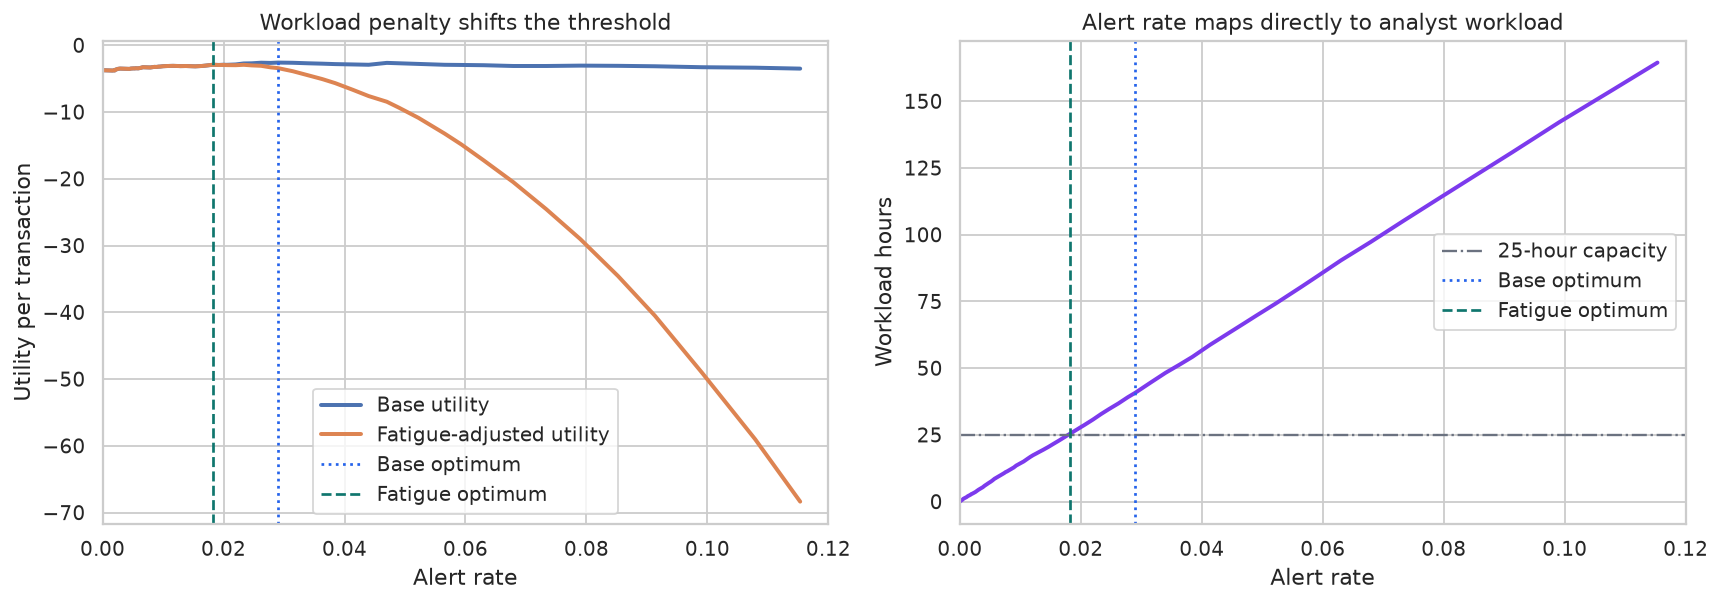

In [12]:
# Section focus: 6. Alert Fatigue and Workload Penalties.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8))

operational_range = fatigue_table.loc[fatigue_table['alert_rate'] <= 0.12].copy()

axes[0].plot(operational_range['alert_rate'], operational_range['utility_per_transaction'], label='Base utility', linewidth=2.2)
axes[0].plot(operational_range['alert_rate'], operational_range['fatigue_adjusted_utility_per_transaction'], label='Fatigue-adjusted utility', linewidth=2.2)
axes[0].axvline(base_best['alert_rate'], color='#2563eb', linestyle=':', linewidth=1.5, label='Base optimum')
axes[0].axvline(fatigue_best['alert_rate'], color='#0f766e', linestyle='--', linewidth=1.5, label='Fatigue optimum')
axes[0].set_title('Workload penalty shifts the threshold')
axes[0].set_xlabel('Alert rate')
axes[0].set_ylabel('Utility per transaction')
axes[0].set_xlim(0, 0.12)
axes[0].legend()

axes[1].plot(operational_range['alert_rate'], operational_range['workload_hours'], color='#7c3aed', linewidth=2.2)
axes[1].axhline(daily_capacity_hours, color='#6b7280', linestyle='-.', linewidth=1.3, label=f'{daily_capacity_hours}-hour capacity')
axes[1].axvline(base_best['alert_rate'], color='#2563eb', linestyle=':', linewidth=1.5, label='Base optimum')
axes[1].axvline(fatigue_best['alert_rate'], color='#0f766e', linestyle='--', linewidth=1.5, label='Fatigue optimum')
axes[1].set_title('Alert rate maps directly to analyst workload')
axes[1].set_xlabel('Alert rate')
axes[1].set_ylabel('Workload hours')
axes[1].set_xlim(0, 0.12)
axes[1].legend()

plt.tight_layout()
plt.show()

The fatigue-adjusted optimum can be more conservative than the base utility optimum because it accounts for the nonlinear cost of overwhelming reviewers. This is an operational design issue. If analysts cannot investigate alerts carefully, the real-world precision of the system may be lower than the offline precision estimate.

In practice, alert fatigue should be managed with thresholding, deduplication, suppression rules, escalation tiers, and feedback from analyst dispositions.

## 7. Segment-Specific Threshold Checks

A single global threshold can create uneven review rates across segments. This may be appropriate if risk differs, but it should be documented. For segment $g$, compute

$$
\mathrm{AlertRate}_g(t) = \Pr(d(t)=1 \mid G=g),
$$

and

$$
\mathrm{Precision}_g(t) = \Pr(Y=1 \mid d(t)=1, G=g).
$$

If one segment receives many alerts with low precision, the threshold may be poorly calibrated for that segment.

In [13]:
chosen_threshold = float(fatigue_best['threshold'])
df['chosen_alert'] = df['anomaly_score'] >= chosen_threshold

segment_policy = []
for segment_name, group in df.groupby('segment'):
    alerted = group.loc[group['chosen_alert']]
    segment_policy.append({
        'segment': segment_name,
        'transactions': len(group),
        'base_anomaly_rate': group['known_anomaly'].mean(),
        'alert_rate': group['chosen_alert'].mean(),
        'precision_among_alerts': alerted['known_anomaly'].mean() if len(alerted) else np.nan,
        'recall': group.loc[group['known_anomaly'] == 1, 'chosen_alert'].mean() if group['known_anomaly'].sum() else np.nan,
        'mean_alert_score': alerted['anomaly_score'].mean() if len(alerted) else np.nan,
    })
segment_policy = pd.DataFrame(segment_policy)
segment_display = segment_policy.copy()
segment_display['mean_alert_score'] = segment_display['mean_alert_score'].map(lambda value: f'{value:.3f}' if pd.notna(value) else '')
for column in ['base_anomaly_rate', 'alert_rate', 'precision_among_alerts', 'recall']:
    segment_display[column] = segment_display[column].map(lambda value: f'{value:.1%}' if pd.notna(value) else '')
smart_display(segment_display, max_width='920px')

,segment,transactions,base_anomaly_rate,alert_rate,precision_among_alerts,recall,mean_alert_score
0,consumer,5237,1.8%,1.1%,16.4%,9.7%,0.336
1,enterprise,1018,2.0%,2.2%,9.1%,10.0%,0.369
2,small_business,2745,3.0%,3.2%,9.2%,9.6%,0.351


Segment-Specific Threshold Checks should be read as an operations question. A useful score separates review-worthy risk from ordinary variation.


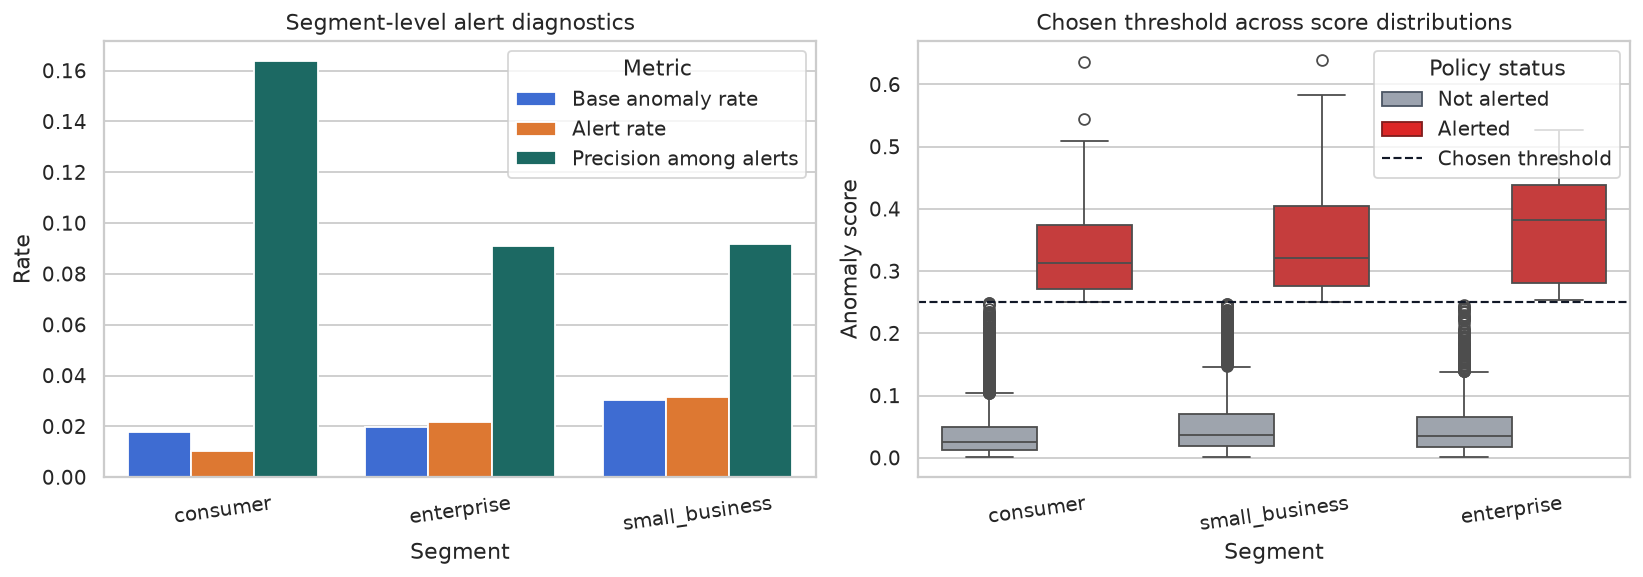

In [14]:
# Section focus: 7. Segment-Specific Threshold Checks.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
segment_plot = segment_policy.melt(
    id_vars='segment',
    value_vars=['base_anomaly_rate', 'alert_rate', 'precision_among_alerts'],
    var_name='metric',
    value_name='value',
)
metric_names = {
    'base_anomaly_rate': 'Base anomaly rate',
    'alert_rate': 'Alert rate',
    'precision_among_alerts': 'Precision among alerts',
}
segment_plot['metric'] = segment_plot['metric'].map(metric_names)
sns.barplot(data=segment_plot, x='segment', y='value', hue='metric', ax=axes[0], palette=['#2563eb', '#f97316', '#0f766e'])
axes[0].set_title('Segment-level alert diagnostics')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=8)
axes[0].legend(title='Metric')

sns.boxplot(data=df, x='segment', y='anomaly_score', hue='chosen_alert', ax=axes[1], palette={False: '#9ca3af', True: '#dc2626'})
axes[1].axhline(chosen_threshold, color='#111827', linestyle='--', linewidth=1.2)
axes[1].set_title('Chosen threshold across score distributions')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Anomaly score')
axes[1].tick_params(axis='x', rotation=8)
axes[1].legend(
    handles=[
        Patch(facecolor='#9ca3af', edgecolor='#4b5563', label='Not alerted'),
        Patch(facecolor='#dc2626', edgecolor='#7f1d1d', label='Alerted'),
        Line2D([0], [0], color='#111827', linestyle='--', linewidth=1.2, label='Chosen threshold'),
    ],
    title='Policy status',
)

plt.tight_layout()
plt.show()

The segment audit asks whether the chosen threshold behaves sensibly across groups. A global threshold is easy to operate, but it may not be the final answer if score distributions, base rates, or false-alert costs vary strongly by segment.

The goal is not to force identical alert rates. The goal is to notice differences, explain them, and decide whether the policy is operationally and ethically defensible.

## 8. Threshold Selection Memo

A threshold memo should make the decision reproducible. It should include the chosen policy, the alternatives considered, the cost assumptions, expected workload, known tradeoffs, and what will be monitored after launch.

In [15]:
# Section focus: 8. Threshold Selection Memo.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

base_overload_hours = float(base_best['over_capacity_hours'])
fatigue_overload_hours = float(fatigue_best['over_capacity_hours'])

memo = pd.DataFrame({
    'Memo item': [
        'Recommended policy',
        'Why not the raw utility optimum?',
        'Expected queue size',
        'Expected precision and recall',
        'Expected workload',
        'Main risk',
        'Monitoring plan',
        'Review cadence',
    ],
    'Decision note': [
        f"Use threshold {chosen_threshold:.3f}, selected from the fatigue-adjusted utility curve.",
        f"The raw utility optimum has higher offline utility before fatigue costs, but it requires {base_best['workload_hours']:.1f} review hours against a {daily_capacity_hours}-hour capacity. The adjusted policy reduces overload from {base_overload_hours:.1f} to {fatigue_overload_hours:.1f} hours.",
        f"Expected alert rate is {fatigue_best['alert_rate']:.1%}, or about {int(fatigue_best['alerts'])} transactions in this batch.",
        f"Expected precision is {fatigue_best['precision']:.1%}; expected recall is {fatigue_best['recall']:.1%}.",
        f"Estimated workload is {fatigue_best['workload_hours']:.1f} analyst hours for this batch.",
        'A stricter threshold may miss some real anomalies; a looser threshold may overload analysts and lower investigation quality.',
        'Track realized precision, alert dispositions, workload, segment alert rates, and score distribution drift.',
        'Revisit threshold weekly during pilot and after any major shift in transaction mix.',
    ],
})
smart_display(memo, max_width='900px')

,Memo item,Decision note
0,Recommended policy,"Use threshold 0.250, selected from the fatigue-adjusted utility curve."
1,Why not the raw utility optimum?,"The raw utility optimum has higher offline utility before fatigue costs, but it requires 40.8 review hours against a 25-hour capacity. The adjusted policy reduces overload from 15.8 to 0.4 hours."
2,Expected queue size,"Expected alert rate is 1.8%, or about 164 transactions in this batch."
3,Expected precision and recall,Expected precision is 11.6%; expected recall is 9.7%.
4,Expected workload,Estimated workload is 25.4 analyst hours for this batch.
5,Main risk,A stricter threshold may miss some real anomalies; a looser threshold may overload analysts and lower investigation quality.
6,Monitoring plan,"Track realized precision, alert dispositions, workload, segment alert rates, and score distribution drift."
7,Review cadence,Revisit threshold weekly during pilot and after any major shift in transaction mix.


In Threshold Selection Memo, the detector earns its keep only if the output sharpens the review queue.


## Key Takeaways

- A threshold is an operational policy.
- Precision, recall, false-positive rate, alert rate, workload, and captured severity all vary with the threshold.
- Precision-recall curves are often more operationally informative than ROC curves when anomalies are rare.
- Expected utility makes cost assumptions explicit, but the assumptions must be owned by the business or risk team.
- Capacity-constrained top-k policies are easy to staff but should still log their realized score cutoffs.
- Alert fatigue can be represented as a workload penalty and should be managed before deployment.
- Segment-level diagnostics help determine whether a global threshold is defensible.
- Every threshold decision should end with a memo that records the policy, assumptions, risks, and monitoring plan.

## References

Chandola, V., Banerjee, A., & Kumar, V. (2009). Anomaly detection. *ACM Computing Surveys, 41*(3), 1-58. [https://doi.org/10.1145/1541880.1541882](https://doi.org/10.1145/1541880.1541882)

Cook, J. A., & Ramadas, V. (2020). When to consult precision-recall curves. *The Stata Journal, 20*(1), 131-148. [https://doi.org/10.1177/1536867X20909693](https://doi.org/10.1177/1536867X20909693)

Hassan, W. U., Guo, S., Li, D., Chen, Z., Jee, K., Li, Z., & Bates, A. (2019). NoDoze: Combatting threat alert fatigue with automated provenance triage. *Network and Distributed System Security Symposium*. [https://doi.org/10.14722/ndss.2019.23349](https://doi.org/10.14722/ndss.2019.23349)

Saito, T., & Rehmsmeier, M. (2016). Precrec: Fast and accurate precision-recall and ROC curve calculations in R. *Bioinformatics, 33*(1), 145-147. [https://doi.org/10.1093/bioinformatics/btw570](https://doi.org/10.1093/bioinformatics/btw570)

Zhou, Z.-H., & Liu, X.-Y. (2010). On multi-class cost-sensitive learning. *Computational Intelligence, 26*(3), 232-257. [https://doi.org/10.1111/j.1467-8640.2010.00358.x](https://doi.org/10.1111/j.1467-8640.2010.00358.x)
